### Particle tracking experiments: Drake Passage (DP)

In [1]:
from parcels import FieldSet, JITParticle, ParticleSet, Variable
from parcels import AdvectionRK4

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
import os
import matplotlib.pyplot as plt 
import numpy as np
import zarr
import xarray as xr
from xgcm import Grid
import cmocean
import warnings
from datetime import datetime, timedelta
import matplotlib as mpl
import gsw

In [4]:
%matplotlib inline
plt.rcParams['font.size'] = '12'
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [5]:
workingdir = '/g/data/jk72/mj0995'
os.chdir(workingdir) 

import functions as func
from functions import DeleteErrorParticle, SampleTS, SampleUV, StuckParticles

In [6]:
savepath = os.path.join(workingdir, 'figures')

In [7]:
# import imp 
# imp.reload(func)

#### Load sea surface height field (absolute dynamic topography, ADT)

In [20]:
ssh_insitu = xr.open_dataset('data/cmems_DP.nc')

#### Load bathymetry dataset

In [12]:
bathy = xr.open_dataset('data/circumpolar_bathy_GEBCO2024.nc')
bathy['depth'] = bathy.elevation*-1
new_bathy = bathy.coarsen(lon=10).mean().coarsen(lat=10).mean()

#### Circumpolar datasets

In [13]:
### Mean dynamic topography (Aviso: MDT-CNES-CLS22)
circumpolar_mdt = xr.open_dataset('data/circumpolar_mdt.nc')

In [14]:
### Eddy kinetic energy: 10-year (2010-2020) average EKE, calculated annually from satellite geostrophic velocities.
circumpolar_eke = xr.open_dataset('data/circumpolar_eke_mean.nc').__xarray_dataarray_variable__

In [15]:
### Sea surface height standard deviation (2010-2020)
circumpolar_ssh_std = xr.open_dataset('data/circumpolar_ssh_std_2010-2020.nc').adt

### Bathymetry map 

In [16]:
### choose date
t = '2018-11-20'

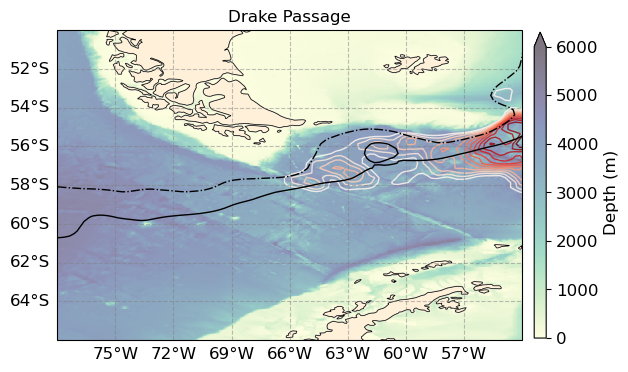

In [27]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 306, -66, -50], crs=ccrs.PlateCarree())

im = new_bathy.depth.plot(vmin = 0, vmax = 6000, 
                          cmap = cmocean.cm.deep, 
                          linestyles = '-', alpha = 0.6, 
                          linewidths = 0.8, add_colorbar = False, 
                          zorder = 0, transform=ccrs.PlateCarree())

### add EKE contours 
circumpolar_eke.plot.contour(levels = np.arange(0.04, 0.1, 0.005), linewidths = 1, cmap = 'Reds', alpha = 0.85, transform=ccrs.PlateCarree())
# circumpolar_ssh_std.plot.contour(levels = np.arange(0.12, 0.24, 0.01),linewidths = 1, cmap = 'magma_r', alpha = 0.85, transform=ccrs.PlateCarree())

### add cartopy features (land, coastlines, lat, lon)
func.map_properties(ax, t, circumpolar_mdt, contours = False)

### MDT contours: long-term mean positions of the Polar Front (PF; solid; -0.3 m) and northern branch of the Subantarctic Front (SAF; dashdot; 0 m) (Sallee et al. 2008; Auger et al. 2024)
circumpolar_mdt.adt.plot.contour(ax = ax, levels=[0], colors='k', linewidths = 1, linestyles = '-.', transform=ccrs.PlateCarree())
circumpolar_mdt.adt.plot.contour(ax = ax, levels=[-0.3], colors='k', linewidths = 1, linestyles = '-', transform=ccrs.PlateCarree())

ax.set_title(r'Drake Passage', fontsize = 12)

cbar_ax = fig.add_axes([0.92, 0.24, 0.02, 0.51]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend = 'max')
cb.set_label('Depth (m)')

In [16]:
# name = f'DP_bathy_map_withEKE.png'
# name = f'DP_bathy_map_with_SSHstd.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches= 0.2)

### SatGEM maps

In [7]:
# ### file paths
# satgem_sal_DP = '/g/data/v45/jw2777/Scripts/Some work for others/new_data_dp/satGEM_sal_DP.nc'
# satgem_temp_DP = '/g/data/v45/jw2777/Scripts/Some work for others/new_data_dp/satGEM_temp_DP.nc'
# gw_DP_data = '/g/data/v45/jw2777/Scripts/Some work for others/new_data_dp/gw_DP_for_maya.nc'

In [8]:
# ### SatGEM on pressure
# gw_DP = xr.open_dataset(gw_DP_data).rename({'lat': 'latitude', 'lon': 'longitude'})
# satgem_DP = xr.open_dataset(satgem_sal_DP)
# temp_DP = xr.open_dataset(satgem_temp_DP)
# satgem_DP['temp'] = temp_DP.temp

In [41]:
### transform to density space
# func.satgem_toDens(satgem_DP, gw_DP, save_to = 'satgem_DP_on_d.nc')

In [17]:
### SatGEM on density
satgem_DP_on_d = xr.open_dataset('data/satgem_DP_on_d.nc')

In [18]:
### set date
t = '2018-11-20'
### set density level
d = 27.1

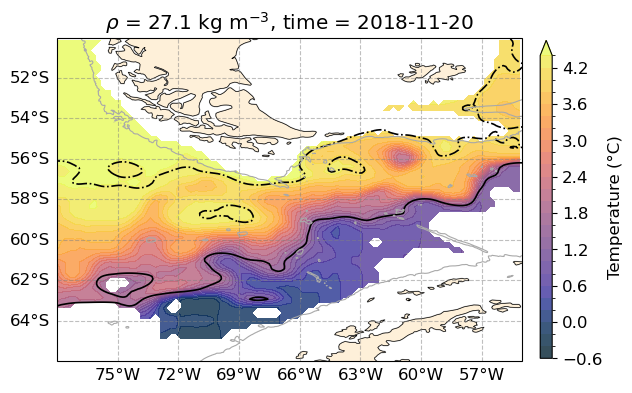

In [21]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 305, -66, -50], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  satgem_DP_on_d.temp.sel(density = d, time = t, method= 'nearest').plot.contourf(cmap = cmocean.cm.thermal, 
                                                                                      levels = np.arange(-0.6, 4.6, 0.2), 
                                                                                      transform=ccrs.PlateCarree(), 
                                                                                      alpha = 0.8,
                                                                                      add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$'+f' = {d}'+ r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Temperature (°C)')

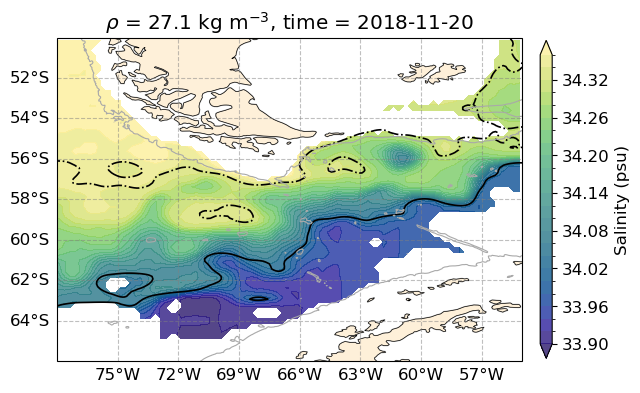

In [22]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 305, -66, -50], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  satgem_DP_on_d.sal.sel(density = d, time = t, method= 'nearest').plot.contourf(cmap = cmocean.cm.haline, 
                                                                                      levels = np.arange(33.9, 34.36, 0.02), 
                                                                                      transform=ccrs.PlateCarree(), 
                                                                                      alpha = 0.8,
                                                                                      add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$'+f' = {d}'+ r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Salinity (psu)')

In [23]:
mask = np.ma.masked_where(abs(satgem_DP_on_d['vgw']) > 2, abs(satgem_DP_on_d['vgw']))
satgem_DP_on_d['vgw'].data[mask.mask] = np.nan

mask = np.ma.masked_where(abs(satgem_DP_on_d['ugw']) > 2, abs(satgem_DP_on_d['ugw']))
satgem_DP_on_d['ugw'].data[mask.mask] = np.nan

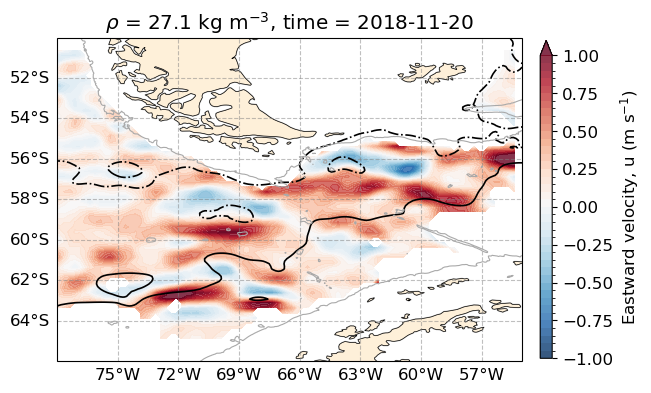

In [24]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 305, -66, -50], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  satgem_DP_on_d.ugw.sel(density = d, time = t, method= 'nearest').plot.contourf(cmap = 'RdBu_r', 
                                                                                     levels = np.arange(-1, 1.05, 0.05),
                                                                                     transform=ccrs.PlateCarree(), 
                                                                                     alpha = 0.8,
                                                                                     add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$'+f' = {d}'+ r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Eastward velocity, u (m s$^{-1}$)')

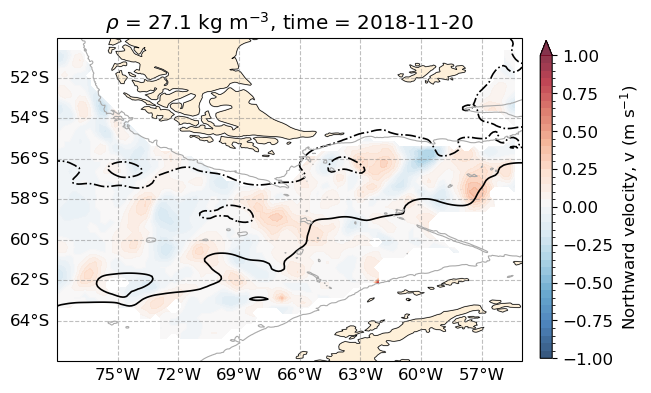

In [25]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 305, -66, -50], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  satgem_DP_on_d.vgw.sel(density = d, time = t, method= 'nearest').plot.contourf(cmap = 'RdBu_r', 
                                                                                     levels = np.arange(-1, 1.05, 0.05),
                                                                                     transform=ccrs.PlateCarree(), 
                                                                                     alpha = 0.8,
                                                                                     add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$'+f' = {d}'+ r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Northward velocity, v (m s$^{-1}$)')

### Add Gaussian noise to the satGEM velocities

In [50]:
dmin, dmax = 27.0, 27.6
satgem_sel = satgem_DP_on_d.sel(density = slice(dmin, dmax))

In [51]:
# gaussian noise scaled by the velocity amplitude (noise increases with velocity amplitude)
mean = 0
pc = 5

scaling_u = (pc/100)*abs(satgem_sel.ugw)
noise_u = np.random.normal(mean, scale = scaling_u)

scaling_v = (pc/100)*abs(satgem_sel.vgw)
noise_v = np.random.normal(mean, scale = scaling_v)

Text(0.5, 1.0, '5% noise u: max=-0.43, min=0.43')

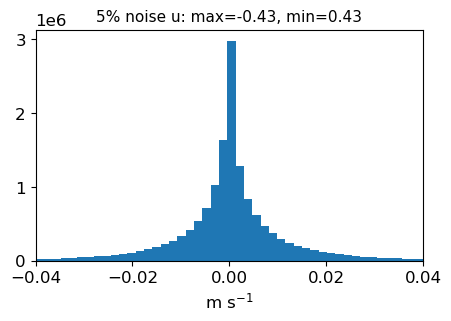

In [52]:
fig, ax = plt.subplots(figsize = (5,3))
plt.hist(noise_u.flatten(), 500)
plt.xlim(-0.04, 0.04)
plt.xlabel('m s$^{-1}$')
plt.title(f'{pc}% noise u: max={np.nanmin(noise_u):.2f}, min={np.nanmax(noise_u):.2f}', fontsize = 11)

Text(0.5, 1.0, '5% noise v: max=-0.55, min=0.41')

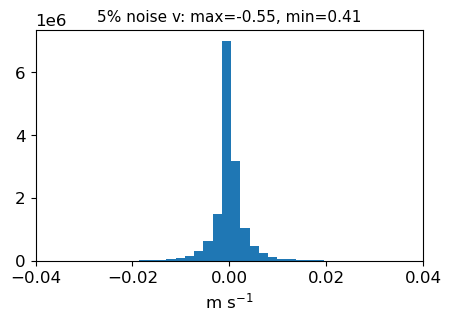

In [53]:
fig, ax = plt.subplots(figsize = (5,3))
plt.hist(noise_v.flatten(), 500)
plt.xlim(-0.04, 0.04)
plt.xlabel('m s$^{-1}$')
plt.title(f'{pc}% noise v: max={np.nanmin(noise_v):.2f}, min={np.nanmax(noise_v):.2f}', fontsize = 11)

In [54]:
# satgem_sel['u_noise'] = satgem_sel.ugw + noise_u
# satgem_sel['v_noise'] = satgem_sel.vgw + noise_v

In [71]:
### save to netcdf 
# satgem_sel.to_netcdf('data/satgem_DP_on_d_noisy.nc')

#### Load SatGEM with noised velocities

In [26]:
satgem_sel = xr.open_dataset('data/satgem_DP_on_d_noisy.nc')

In [27]:
mask = np.ma.masked_where(abs(satgem_sel['v_noise']) > 2, abs(satgem_sel['v_noise']))
satgem_sel['v_noise'].data[mask.mask] = np.nan

mask = np.ma.masked_where(abs(satgem_sel['u_noise']) > 2, abs(satgem_sel['u_noise']))
satgem_sel['u_noise'].data[mask.mask] = np.nan

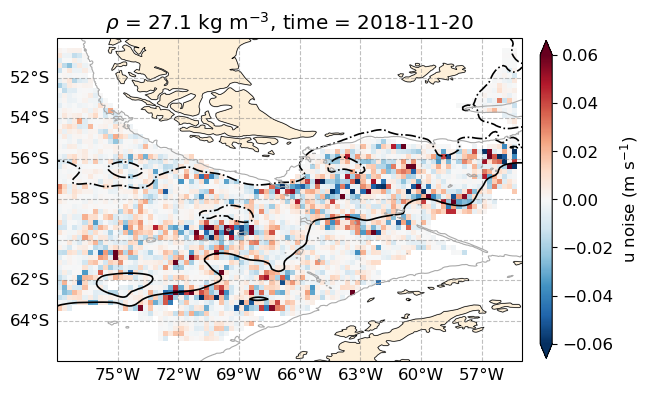

In [28]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 305, -66, -50], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  (satgem_sel.ugw - satgem_sel.u_noise).sel(density = d, time = t, method= 'nearest').plot(cmap = 'RdBu_r', 
                                                                            vmin = -0.06, vmax = 0.06,
                                                                            transform=ccrs.PlateCarree(), 
                                                                            add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$'+f' = {d}'+ r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend = 'both')
cb.set_label('u noise (m s$^{-1}$)')

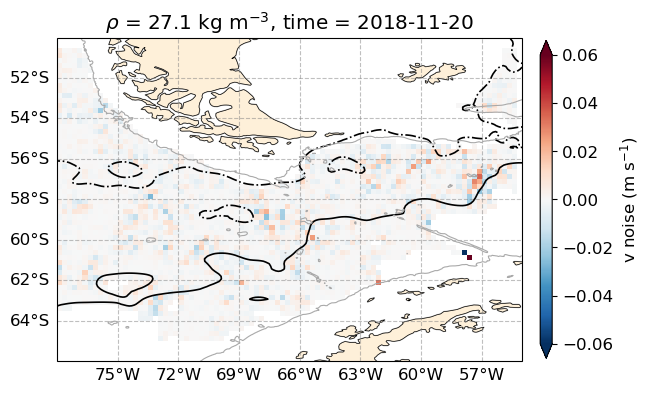

In [29]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 305, -66, -50], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  (satgem_sel.vgw - satgem_sel.v_noise).sel(density = d, time = t, method= 'nearest').plot(cmap = 'RdBu_r', 
                                                                            vmin = -0.06, vmax = 0.06,
                                                                            transform=ccrs.PlateCarree(), 
                                                                            add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$'+f' = {d}'+ r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend = 'both')
cb.set_label('v noise (m s$^{-1}$)')

In [30]:
### time index
t0 = np.where(satgem_sel.time == satgem_sel.time.sel(time = t, method = 'nearest'))[0][0]

days = 10
start = satgem_sel.time[t0-days].data
end = satgem_sel.time[t0].data
print(start, end)

2018-11-10T00:00:00.000000000 2018-11-20T00:00:00.000000000


In [31]:
t_sel = satgem_sel.temp.sel(time = slice(start, end))
t_grad = func.sshGrad(t_sel)

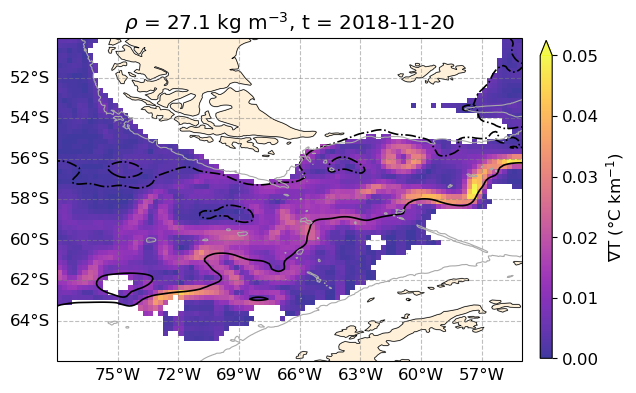

In [32]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 305, -66, -50], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im  = t_grad.sel(density = d, time = t, method = 'nearest').plot(cmap = 'plasma', 
                                                                 vmin = 0, vmax = 0.05,
                                                                 transform=ccrs.PlateCarree(), 
                                                                 add_colorbar = False, 
                                                                 alpha = 0.8, zorder = 0)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$ = ' + f'{d}' + r' kg m$^{-3}$, t = ' + t)

cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend = 'max')
cb.set_label(r'$\nabla$T (°C km$^{-1}$)')

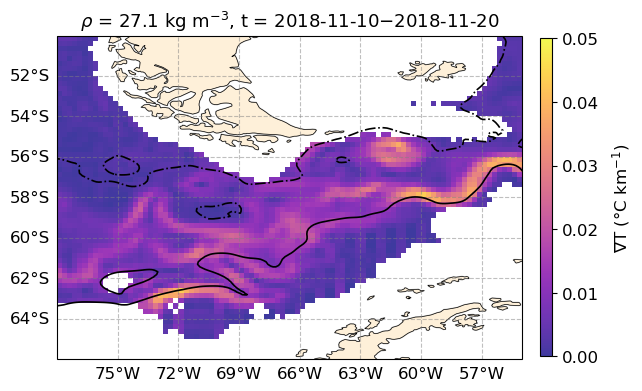

In [58]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 305, -66, -50], crs=ccrs.PlateCarree())

func.map_properties(ax, slice(satgem_sel.time[t0-days], satgem_sel.time[t0]), ssh_insitu)

im  = t_grad.sel(density = d, method = 'nearest').mean(dim = 'time').plot(cmap = 'plasma', 
                                                                            vmin = 0, vmax = 0.05,
                                                                            transform=ccrs.PlateCarree(), 
                                                                            add_colorbar = False, 
                                                                            alpha = 0.8, zorder = 0)

start = str(satgem_sel.time[t0-days].data.astype('M8[D]'))
end = str(satgem_sel.time[t0].data.astype('M8[D]'))
plt.title(r'$\rho$ = ' + f'{d}' + r' kg m$^{-3}$, t = ' + start + '$-$' + end, fontsize = 13)

cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'$\nabla$T (°C km$^{-1}$)', labelpad = 8)

In [60]:
u = satgem_sel.u_noise.sel(time = slice(start, end))
v = satgem_sel.v_noise.sel(time = slice(start, end))

speed = np.sqrt(u**2+v**2)
eke = func.EKE(u, v, u.time[0].values, u.time[-1].values)

mean u and v between 2018-11-10 and 2018-11-20


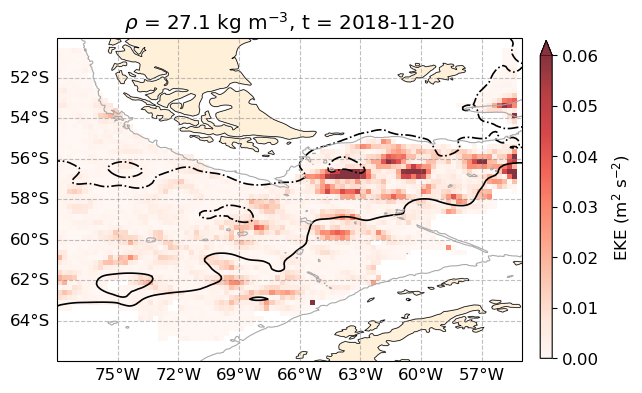

In [61]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 305, -66, -50], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im  = eke.sel(density = d, time = t, method = 'nearest').plot(cmap = 'Reds', 
                                                                vmin = 0, vmax = 0.06,
                                                                transform=ccrs.PlateCarree(), 
                                                                add_colorbar = False, 
                                                                alpha = 0.8, zorder = 0)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$ = ' + f'{d}' + r' kg m$^{-3}$, t = ' + t)

cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend = 'max')
cb.set_label(r'EKE (m$^{2}$ s$^{-2}$)', labelpad = 8)

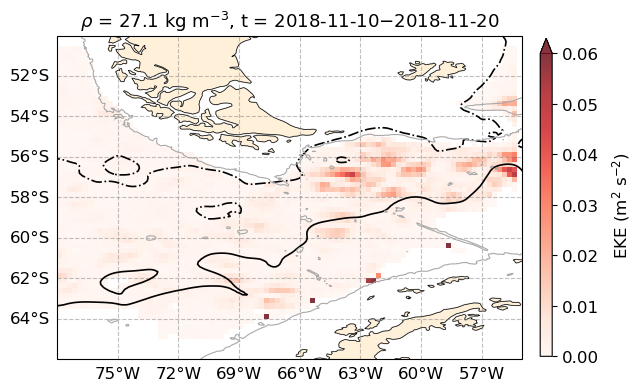

In [62]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 305, -66, -50], crs=ccrs.PlateCarree())

func.map_properties(ax, slice(satgem_sel.time[t0-days], satgem_sel.time[t0]), ssh_insitu, contours = True)

im  = eke.sel(density = d, method = 'nearest').mean(dim = 'time').plot(cmap = 'Reds', 
                                                                vmin = 0, vmax = 0.06,
                                                                transform=ccrs.PlateCarree(), 
                                                                add_colorbar = False, 
                                                                alpha = 0.8, zorder = 0)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$ = ' + f'{d}' + r' kg m$^{-3}$, t = ' + start + '$-$' + end, fontsize = 13)

cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend = 'max')
cb.set_label(r'EKE (m$^{2}$ s$^{-2}$)', labelpad = 8)

### Ocean Parcels setup

In [97]:
variables = {"U": "u_noise", "V": "v_noise", "T": "temp", "S": "sal"}

dimensions = {
    "U": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
    "V": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
    "T": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
    "S": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
}

In [98]:
fieldset = FieldSet.from_xarray_dataset(satgem_sel, variables, dimensions,
                                        interp_method={"U": "partialslip",
                                                       "V": "partialslip",
                                                       "T" : "linear_invdist_land_tracer",
                                                       "S" : "linear_invdist_land_tracer",})

In [14]:
### underlying SatGEM fields to be sampled along the particle trajectories 
SampleParticle = JITParticle.add_variables(
    ["temp", "sal",
     Variable("U", dtype=np.float32, initial=np.nan),
     Variable("V", dtype=np.float32, initial=np.nan)])

### Meridional section of particles

In [38]:
### set intial time to release particles
t = '2018-11-20'
t0 = np.where(satgem_sel.time == satgem_sel.time.sel(time = t, method = 'nearest'))[0][0]

In [39]:
### particle release coordinates (lat and lon)
lon0 = 298 #longitide (degrees E)
y = np.arange(-60.5, -55, 0.1) #latitude (degrees N)

# lon0 = 288
# y = np.arange(-62, -56.5, 0.1) 

x = np.tile(lon0, y.shape)

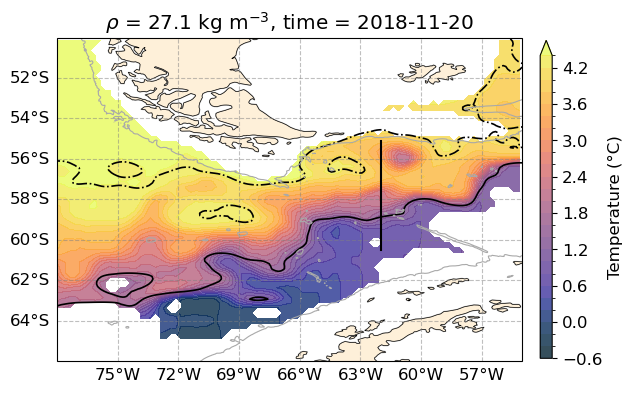

In [40]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([282, 305, -66, -50], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  satgem_DP_on_d.temp.sel(density = d, time = t, method= 'nearest').plot.contourf(cmap = cmocean.cm.thermal, 
                                                                                      levels = np.arange(-0.6, 4.6, 0.2), 
                                                                                      transform=ccrs.PlateCarree(), 
                                                                                      alpha = 0.8,
                                                                                      add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.plot(x, y, transform=ccrs.PlateCarree(), c = 'k')

plt.title(r'$\rho$'+f' = {d}'+ r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Temperature (°C)')

In [41]:
### set density range
dens_interval = 0.01
dens = np.arange(27.1, 27.5, dens_interval)

In [42]:
### repeat to 2D 
xx = np.repeat(x[:, np.newaxis], len(dens), axis=1)
yy = np.repeat(y[:, np.newaxis], len(dens), axis=1)
dens_2d = np.repeat(dens[np.newaxis, :], xx.shape[0], axis=0)

In [43]:
n_particles = len(xx.flatten())
time = np.tile(satgem_sel.time[t0].data, n_particles)

In [44]:
### advection time
n_days = 15

lons = xx
lats = yy

In [45]:
pc = 5 # noise percentage (of velocities)
timestep = 6 #hours

### Run particle advection

In [37]:
# pset = ParticleSet(
#     fieldset=fieldset, pclass=SampleParticle, lon=lons, lat=lats, time=time, depth = dens_2d
# )

# # filename = f'output/DP/MeridionalSection_{lon0}_{n_days}days_with_noise_gaussian_{pc}.zarr'
# filename = f'output/DP/MeridionalSection_{lon0}_{n_days}days_{pc}noise_{t}.zarr'
# output_file = pset.ParticleFile(name=filename, outputdt=timedelta(hours=timestep))

# # set dt to negative for backward advection
# dt = -timedelta(hours=timestep)

# pset.execute(
#     [AdvectionRK4, SampleTS, SampleUV, StuckParticles],
#     runtime=timedelta(days=n_days),
#     dt=dt,
#     output_file=output_file,
# )

#### Load saved particle advection file

In [63]:
pc = 5
filename = f'output/DP/MeridionalSection_{lon0}_{n_days}days_{pc}noise_{t}.zarr'

In [64]:
ds_out = xr.open_zarr(filename)
df = ds_out.to_dataframe()

### Plot results

In [65]:
### after 10 days
days = 10
sample_interval = int(24/timestep)
t_ind = days*sample_interval

In [66]:
start = satgem_sel.time[t0-days].data
end = satgem_sel.time[t0].data
print('release time t0: ', end)
print('t0 -10 days: ', start)

release time t0:  2018-11-20T00:00:00.000000000
t0 -10 days:  2018-11-10T00:00:00.000000000


In [67]:
### calculate EKE from the SatGEM velocities on the 27.1 isopycnal, for the 10 day advection period.
d = 27.1
u = satgem_sel.u_noise.sel(density = d, method = 'nearest').sel(time = slice(start, end))
v = satgem_sel.v_noise.sel(density = d, method = 'nearest').sel(time = slice(start, end))

mask = np.ma.masked_where(abs(u) > 1.5, abs(u))
u.data[mask.mask] = np.nan
mask = np.ma.masked_where(abs(v) > 1.5, abs(v))
v.data[mask.mask] = np.nan

eke = func.EKE(u, v, u.time[0].values, u.time[-1].values)

mask = np.ma.masked_where(eke > 0.1, eke)
eke.data[mask.mask] = np.nan

mean u and v between 2018-11-10 and 2018-11-20


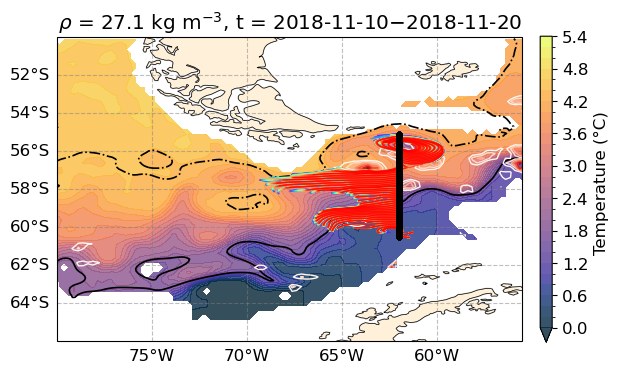

In [71]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([280, 304.5, -66, -50], crs=ccrs.PlateCarree())

n = len(dens)
colors = plt.cm.rainbow(np.linspace(0,1,n))

### plot PF and nSAF locations (ADT contours)
func.map_properties(ax, slice(satgem_sel.time[t0-days], satgem_sel.time[t0]), ssh_insitu, contours = True)

### plot particle trajectories (rainbow)
i = 0
for di in dens:
    df_sel = df.loc[df['z'] == di]
    im = plt.plot(df_sel.to_xarray().lon.T[0:t_ind+1], df_sel.to_xarray().lat.T[0:t_ind+1], 
                  c = colors[i], alpha = 0.6, linewidth = 0.9, 
                  transform=ccrs.PlateCarree(), zorder = 10)
    i +=1   
ax.legend_ = None

### plot particle release locations (black)
plt.plot(ds_out.lon[:, 0], ds_out.lat[:, 0], "o", ms = 3, c = 'k', alpha=0.5, transform=ccrs.PlateCarree(), zorder = 12)

### plot satgem temperature field
meanT = satgem_sel.temp.sel(time = slice(satgem_sel.time[t0-days], satgem_sel.time[t0])).mean('time')
im = meanT.sel(density = d, method = 'nearest').plot.contourf(cmap = cmocean.cm.thermal, 
                                                                    levels = np.arange(0, 5.6, 0.2), 
                                                                    transform=ccrs.PlateCarree(), 
                                                                    add_colorbar = False, 
                                                                    alpha = 0.8, zorder = 0)

### plot EKE contours (red)
mean_eke = eke.sel(time = slice(start, end)).mean(dim  = 'time')
mean_eke.plot.contour(levels = np.arange(0.01, 0.05, 0.005), cmap = 'Reds', linewidths = 1, zorder = 2,
                                                             transform=ccrs.PlateCarree(), add_colorbar = False)

start = str(satgem_sel.time[t0-days].data.astype('M8[D]'))
end = str(satgem_sel.time[t0].data.astype('M8[D]'))
plt.title(r'$\rho$ = ' + f'{d}' + r' kg m$^{-3}$, t = ' + start + '$-$' + end)

cbar_ax = fig.add_axes([0.93, 0.24, 0.02, 0.51]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Temperature (°C)')

In [72]:
# name = f'DP_particle_map_{lon0}_{t}.png'
# fig.savefig(os.path.join(savepath, name), dpi = 400, bbox_inches='tight', pad_inches= 0.2)

### Extract T-S properties

In [ ]:
col_idx = np.arange(0, len(ds_out.trajectory), len(dens))

In [128]:
### T-S at particle origin locations (e.g. -10 days)
originT, originS = func.origin_TS(ds_out, col_idx, t_ind, dens)

In [129]:
### T-S at particle release locations (e.g. 0 days)
seed_temp = ds_out.temp[:, 0]
seed_sal = ds_out.sal[:, 0]

In [130]:
### density contours for T-S diagram 
ti, si, dens_contour = func.tsDensContour(seed_sal, seed_temp)

#### T-S diagram

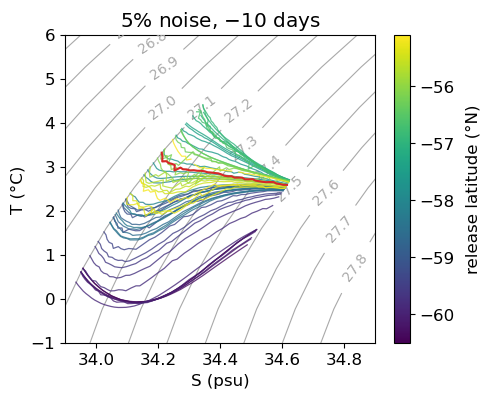

In [131]:
fig, ax = plt.subplots(figsize = (5, 4))

### draw density contours
CS = ax.contour(si, ti, dens_contour, levels = np.arange(26.4, 27.9, 0.1), linewidths = 0.8, colors='darkgrey')
plt.clabel(CS, inline=1, fontsize=10, fmt = '%1.1f')

n = len(y)
colors = plt.cm.viridis(np.linspace(0,1,n))

### plot reconstructed profiles
k = 0
for prof in range(len(originS)): 
    im = ax.plot(originS[prof], originT[prof], c= colors[k], linewidth = 0.9, alpha = 0.8, zorder= 20)
    k+=1

### highlight a particlar profile in red (lt = latitude of particle release column)
lt = -55.9 
ax.plot(originS.sel(latitude = lt, method = 'nearest'), originT.sel(latitude = lt, method = 'nearest'), c = 'tab:red', zorder = 100)

plt.xlim(33.9,34.9)
plt.ylim(-1, 6)
plt.ylabel('T (°C)')
plt.xlabel('S (psu)')

### add colourbar
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(y), vmax=max(y)))
cb = plt.colorbar(sm, ax=ax)
cb.set_label(label = 'release latitude (°N)', labelpad = 8)

plt.title(f'{pc}% noise, $-${days} days')
# plt.title(f'longitude: {360-lon0}°W', fontsize = 13)
# plt.title(f'longitude: {360-lon0}°W ({lon0}°E), $-${days} days', fontsize = 12)
plt.show()

In [132]:
# name = f'DP_TS_{lon0}_{t}.png'
# # name = f'DP_TS_{lon0}_{lt}_{t}.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches= 0.2)

#### Individual particle column 3D plot

In [133]:
### index of highlighted profile
i = np.where(ds_out.lat[:, 0] == lt)[0][0]

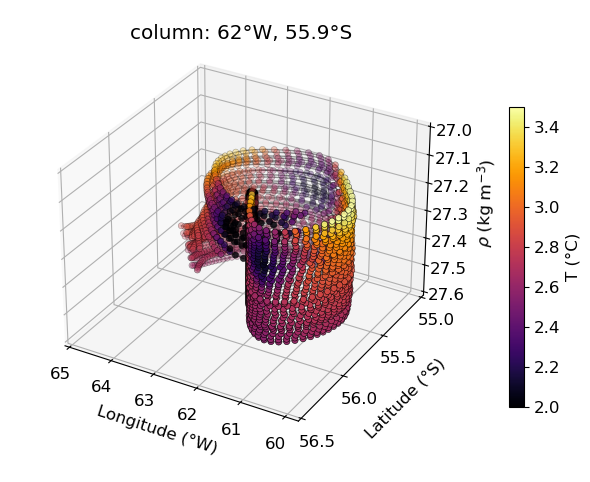

In [134]:
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d')

### loop through density levels
for d in range(i, i+len(dens)):
    
    ### release location
    ax.scatter(ds_out.lon[d, 0], ds_out.lat[d, 0], zs = ds_out.z[d, 0], facecolors = 'none', linewidth = 5, edgecolor = 'k', s=20, zorder = np.inf)

    ### particle locations
    ax.plot(ds_out.lon[d, :].T, ds_out.lat[d, :].T, zs = ds_out.z[d, :].T, c = 'k', linewidth = 1, alpha = 0.4)
    
    ### colour by underlying SatGEM temperature properties
    im = ax.scatter(ds_out.lon[d, :].T, ds_out.lat[d, :].T, zs = ds_out.z[d, :].T, 
                    c = ds_out.temp[d, :].T, cmap=plt.cm.inferno, 
                    norm=mpl.colors.Normalize(vmin=2, vmax=3.5),
                    edgecolor="k", zorder=2, linewidth = 0.4, s=20)


ax.set_zlim(27, 27.6)
ax.invert_zaxis()

ax.set_yticks(np.arange(-56.5, -54.6, 0.5)) #np.arange(-58, -56, 0.5)
ax.set_yticklabels(np.arange(56.5, 54.6, -0.5)) #np.arange(58, 56, -0.5)

ax.set_xticks(np.arange(295, 301, 1)) #np.arange(282, 292, 2))
ax.set_xticklabels(np.arange(360-295, 360-301, -1))

ax.set_box_aspect(aspect=None, zoom=0.9)

ax.set_ylabel('Latitude (°S)', labelpad = 10)
ax.set_xlabel('Longitude (°W)', labelpad = 6)
ax.set_zlabel(r'$\rho$ (kg m$^{-3}$)', labelpad = 8)

plt.colorbar(im, label="T (°C)", aspect = 20, shrink = 0.65, pad = 0.06, anchor = (0, 0.4))
plt.title(f'column: {360-lon0}°W, {abs(ds_out.lat[i, 0]).values:.1f}°S', y = 1)
ax.view_init(elev=30, azim=-60)
# plt.tight_layout()
plt.show()

In [40]:
# name = f'DP_col_{lon0}_{lt}_{t}.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches= 0.2)

#### T-S evolution 

In [135]:
### set time indices (e.g. for 0, -5, -10 and -15 days) 
day_ind = [0, 20, 40, -1]
colors = plt.cm.plasma(np.linspace(0,1,len(day_ind)+1))

Text(0.5, 1.0, 'column: 62°W, 55.9°S')

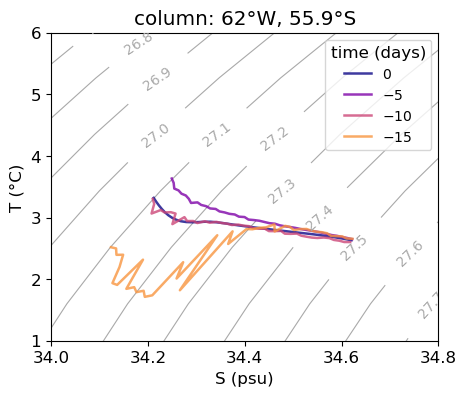

In [136]:
fig, ax = plt.subplots(figsize = (5, 4))

### draw density contours
CS = ax.contour(si, ti, dens_contour, levels = np.arange(26.4, 27.9, 0.1), linewidths = 0.8, colors='darkgrey')
plt.clabel(CS, inline=1, fontsize=10, fmt = '%1.1f')

### plot reconstructed T-S profiles at different time steps
k = 0
for day in day_ind:
    plt.plot(ds_out.sal[i:i+len(dens), day], ds_out.temp[i:i+len(dens), day], linewidth = 1.8, color = colors[k], alpha = 0.8)
    k+=1

plt.legend([r'0', r'$-$5', r'$-$10', r'$-$15'], fontsize = 10, title = 'time (days)', loc = 'upper right')
plt.xlim(34,34.8)
plt.ylim(1, 6)
plt.ylabel('T (°C)')
plt.xlabel('S (psu)')

plt.title(f'column: {360-lon0}°W, {abs(ds_out.lat[i, 0]).values:.1f}°S')

In [82]:
# name = f'DP_col_{lon0}_{lt}_{t}_evolution.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches= 0.2)

### Calculate DSC from reconstructed T-S profiles 

In [137]:
dsc = func.DSC(originT, originS, dens_2d, vert_smooth = False, x_smooth = False)

Text(0.5, 1.0, 'longitude: 62°W')

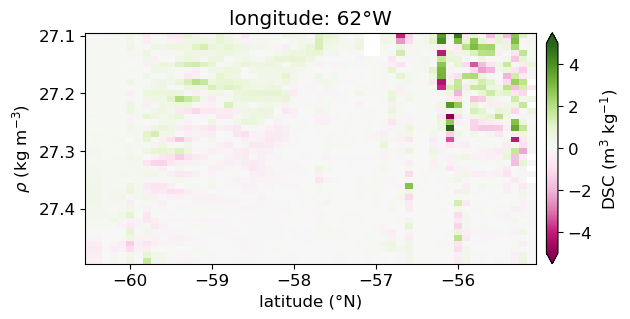

In [138]:
fig, ax = plt.subplots(figsize=(7, 3))
dsc.plot(x = 'latitude', cmap = 'PiYG', vmin = -5, vmax = 5, 
         cbar_kwargs = dict(label = r'DSC (m$^{3}$ kg$^{-1}$)', pad = 0.02))

ax.invert_yaxis()
ax.set_ylabel(r'$\rho$ (kg m$^{-3}$)')
plt.xlabel('latitude (°N)')
plt.title(f'longitude: {360-lon0}°W')

In [140]:
### open saved dataset
ds = xr.open_dataset(f'/g/data/jk72/mj0995/summary_stats/DP_MeridionalSection_{lon0}_{t}_10days.nc')

Text(0.5, 1.0, 'longitude: 62°W')

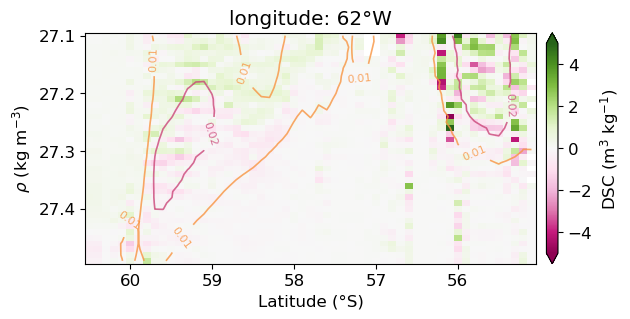

In [141]:
### plot DSC with T gradient contours
fig, ax = plt.subplots(figsize=(7, 3))
ds.DSC.plot(x = 'latitude', cmap = 'PiYG', vmin = -5, vmax = 5, cbar_kwargs = dict(label = r'DSC (m$^{3}$ kg$^{-1}$)', pad = 0.02))

## isopycnal temperature gradients from SatGEM-2 averaged along the particle trajectory
CS = ds.T_grad.plot.contour(x = 'latitude', cmap = 'plasma_r', levels = np.arange(0, 0.05, 0.01), linewidths = 1.2, alpha = 0.8)
plt.clabel(CS, np.arange(0, 0.05, 0.01), fontsize = 8)

ax.invert_yaxis()
ax.set_xticks(np.arange(-60, -55, 1))
ax.set_xticklabels(np.arange(60, 55, -1))

ax.set_ylabel(r'$\rho$ (kg m$^{-3}$)')
plt.xlabel('Latitude (°S)')
plt.title(f'longitude: {360-lon0}°W')

In [70]:
# name = f'DP_DSC_{lon0}_{t}.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches= 0.2)

### Trajectory statistics

In [142]:
days = 10
t_ind = 40

In [143]:
start = satgem_sel.time[t0-days].data
end = satgem_sel.time[t0].data
print(start, end)

2018-11-10T00:00:00.000000000 2018-11-20T00:00:00.000000000


#### Cumulative distance travelled 

In [144]:
dist_travelled = func.distance_travelled(ds_out, col_idx, t_ind, dens)

Text(0, 0.5, 'cumulative distance (km)')

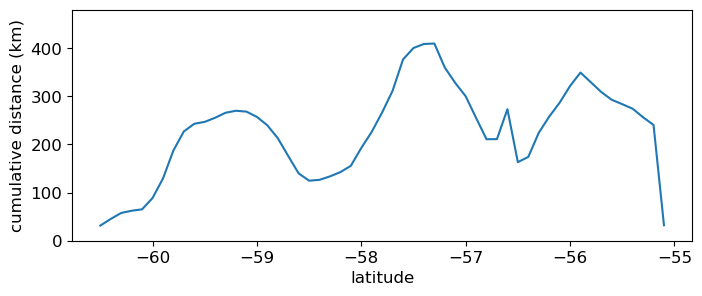

In [145]:
fig, ax = plt.subplots(figsize = (8,3))
dist_travelled.mean(dim = 'potential_density').plot()
plt.ylim(0, 480)
plt.ylabel('cumulative distance (km)')

#### DSC generation: number of days for depth-averaged DSC magnitude to exceed 1 m$^{3}$ kg$^{-1}$

In [141]:
dsc_gen = func.all_cols_dsc_generation(ds_out, col_idx, t_ind, dens)
dsc_gen = xr.DataArray(dsc_gen, dims = dsc.dims, coords = dsc.coords)

In [146]:
# fig, ax = plt.subplots(figsize=(7, 2.5))
# dsc_gen.plot(x = 'latitude', cmap = 'plasma_r', vmin = 0, vmax = 15, 
#             cbar_kwargs = dict(label = 'n_days'))

# plt.title('Days for depth-avg DSC magnitude to reach > 1 m^3/kg', fontsize = 10)

#### Average isopycnal temperature gradient along the particle trajectories

In [ ]:
avg_t_grad = func.col_trajectory_avg(ds_out, t_grad, col_idx, t_ind, dens)
avg_t_grad = xr.DataArray(avg_t_grad, dims = dsc.dims, coords = dsc.coords)

Text(0.5, 1.0, 'trajectory-averaged $\\nabla$T')

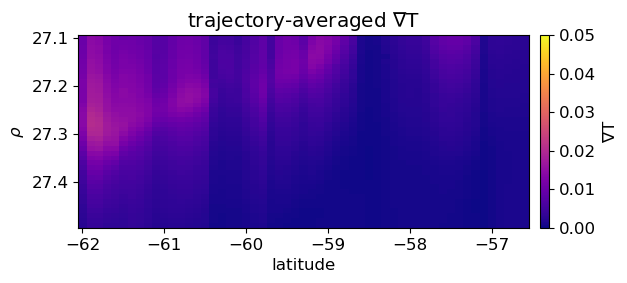

In [146]:
fig, ax = plt.subplots(figsize=(7, 2.5))
avg_t_grad.plot(x = 'latitude', cmap = 'plasma', vmin = 0, vmax = 0.05, cbar_kwargs = dict(label = r'$\nabla$T', pad = 0.02))

ax.invert_yaxis()
ax.set_ylabel(r'$\rho$')
plt.title(r'trajectory-averaged $\nabla$T')

#### Average EKE along the particle trajectories

In [ ]:
avg_eke = func.col_trajectory_avg(ds_out, eke, col_idx, t_ind, dens)
avg_eke = xr.DataArray(avg_eke, dims = dsc.dims, coords = dsc.coords)

Text(0.5, 1.0, 'trajectory-averaged EKE')

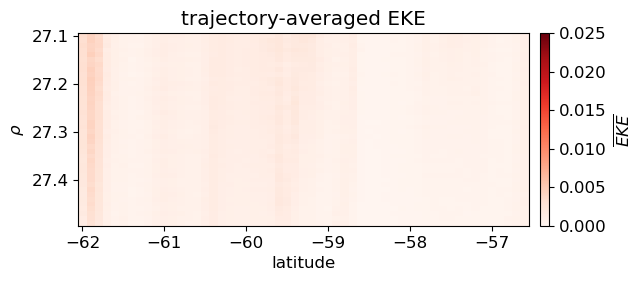

In [149]:
fig, ax = plt.subplots(figsize=(7, 2.5))
avg_eke.plot(x = 'latitude', cmap = 'Reds', vmin = 0, vmax = 0.025, cbar_kwargs = dict(label = r'$\overline{EKE}$', pad = 0.02))

ax.invert_yaxis()
ax.set_ylabel(r'$\rho$')
plt.title(r'trajectory-averaged EKE')

#### Average speed along the particle trajectories

In [151]:
avg_speed = func.col_trajectory_avg(ds_out, speed, col_idx, t_ind, dens)
avg_speed = xr.DataArray(avg_speed, dims = dsc.dims, coords = dsc.coords)

Text(0.5, 1.0, 'trajectory-averaged speed')

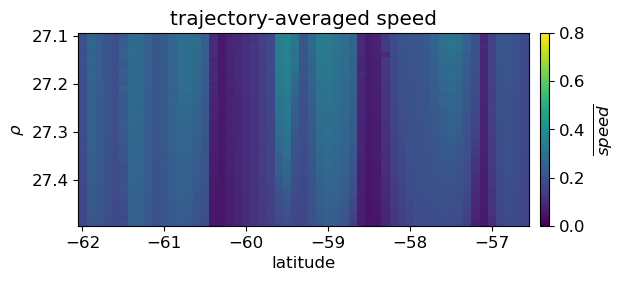

In [152]:
fig, ax = plt.subplots(figsize=(7, 2.5))
avg_speed.plot(x = 'latitude', cmap = 'viridis', vmin = 0, vmax = 0.8, 
         cbar_kwargs = dict(label = r'$\overline{speed}$', pad = 0.02))
ax.invert_yaxis()
ax.set_ylabel(r'$\rho$')
plt.title(r'trajectory-averaged speed')

#### Save summary statistics to netcdf

In [153]:
print(f'{lon0}E')
print(t, f'{days} days')

288E
2018-10-31 10 days


In [154]:
# ds = avg_t_grad.to_dataset(name="T_grad")
# ds.T_grad.attrs = {"description": "horizontal temperature gradient averaged along the particle trajectories"}

# ds["DSC"] = dsc
# ds.DSC.attrs = {"description": "diapycnal spiciness curvatrue (dsc) calculated using particle origin T and S"}

# ds["EKE"] = avg_eke
# ds.EKE.attrs = {"description": "average EKE along the particle trajectories"}

# ds['dsc_generation'] = dsc_gen
# ds.dsc_generation.attrs = {"description": "number of days for depth-avg DSC magnitude to reach 1 m$^{3}$ kg$^{-1}$"}

# ds['speed'] = avg_speed
# ds.speed.attrs = {"description": "Average current speed experienced by the particles along their trajectories"}

# ds['cum_dist'] = xr.DataArray(dist_travelled.data, dims = ds.T_grad.dims)
# ds.cum_dist.attrs = {"description": "cumulative distance travelled by each particle (km)"}

# ds.attrs = {"description": f"Meridional section of particles released at {lon0}E on {t} and advected backward-in-time for {days} days"}

In [155]:
ds

<xarray.Dataset> Size: 106kB
Dimensions:            (potential_density: 40, latitude: 55)
Coordinates:
  * potential_density  (potential_density) float64 320B 27.1 27.11 ... 27.49
  * latitude           (latitude) float32 220B -62.0 -61.9 -61.8 ... -56.7 -56.6
Data variables:
    T_grad             (latitude, potential_density) float64 18kB 0.01011 ......
    DSC                (latitude, potential_density) float64 18kB -0.6243 ......
    EKE                (latitude, potential_density) float64 18kB 0.003369 .....
    dsc_generation     (latitude, potential_density) float64 18kB 99.0 ... 99.0
    speed              (latitude, potential_density) float64 18kB 0.1996 ... ...
    cum_dist           (latitude, potential_density) float64 18kB 160.8 ... 1...
Attributes:
    description:  Meridional section of particles released at 288E on 2018-10...

In [156]:
# ds.to_netcdf(f'summary_stats/DP_MeridionalSection_{lon0}_{t}_{days}days.nc')